# Baseline Analysis

In [6]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

In [7]:
results = pd.read_csv(DATA_DIR / "baseline_results.csv")

results.head()

,topology,trial,n,beta,gamma,t10,t50,peak_infected,auc,final_size,duration
0,ER,0,1000,0.15,0.05,6,10,706,19207.5,0.986,153
1,ER,1,1000,0.15,0.05,5,9,725,20140.5,0.987,167
2,ER,2,1000,0.15,0.05,5,9,746,20514.5,0.994,140
3,ER,3,1000,0.15,0.05,7,11,711,19102.5,0.991,136
4,ER,4,1000,0.15,0.05,6,10,720,19185.5,0.991,162


In [8]:
summary = results.groupby("topology")[[
    "t10",
    "t50",
    "peak_infected",
    "final_size",
    "auc"
]].agg(["mean", "std"])

summary

t10              t50           peak_infected            final_size  \
          mean       std   mean       std          mean        std       mean   
topology                                                                        
BA        4.76  0.975663   7.90  1.000000        738.21  15.577305    0.99501   
ER        6.14  0.778758  10.41  0.888706        728.26  15.224661    0.99041   
WS        8.73  1.153431  17.76  1.511705        639.02  21.357931    0.99961   

                         auc              
               std      mean         std  
topology                                  
BA        0.002699  19825.07  676.544970  
ER        0.003397  19844.99  530.899665  
WS        0.000650  19906.70  634.582086

## Average Time to Reach 50% Infection

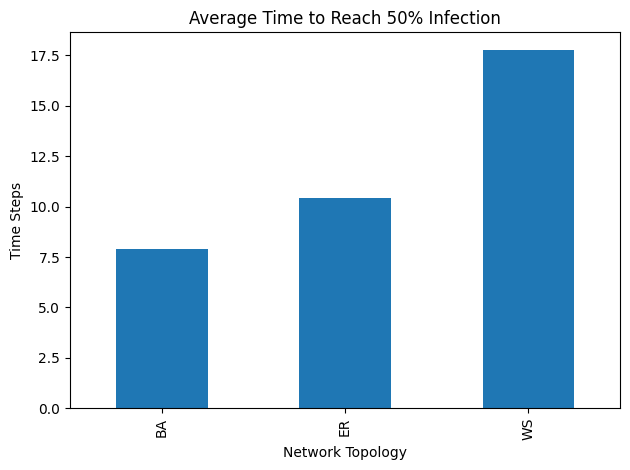

In [9]:
t50_mean = results.groupby("topology")["t50"].mean()

plt.figure()
t50_mean.plot(kind="bar")
plt.ylabel("Time Steps")
plt.xlabel("Network Topology")
plt.title("Average Time to Reach 50% Infection")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_t50_bar.png", dpi=300)
plt.show()

## Peak Active Misinformation Spreaders

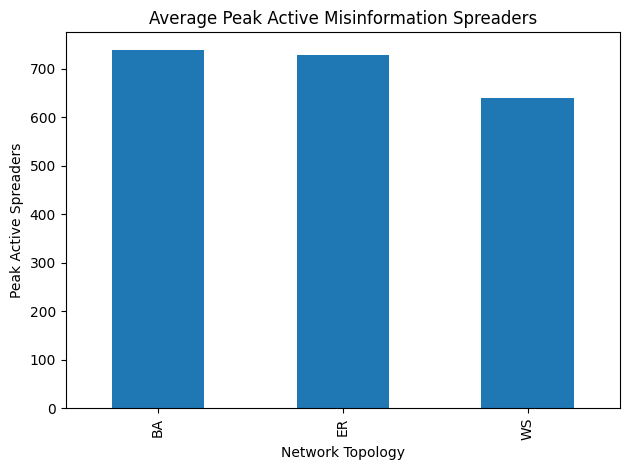

In [10]:
peak_mean = results.groupby("topology")["peak_infected"].mean()

plt.figure()
peak_mean.plot(kind="bar")
plt.ylabel("Peak Active Spreaders")
plt.xlabel("Network Topology")
plt.title("Average Peak Active Misinformation Spreaders")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_peak_bar.png", dpi=300)
plt.show()

## Final Outbreak Size

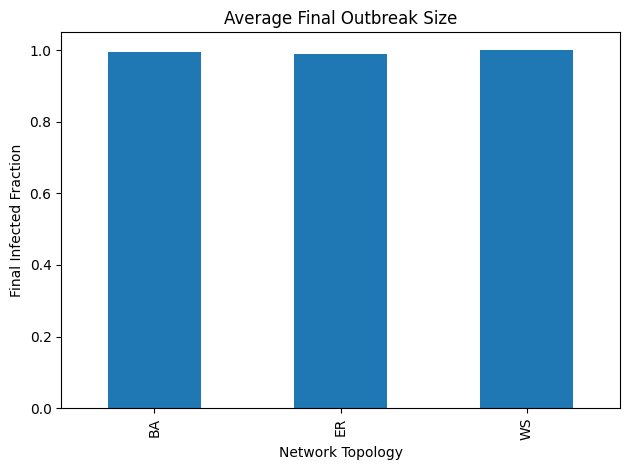

In [11]:
final_mean = results.groupby("topology")["final_size"].mean()

plt.figure()
final_mean.plot(kind="bar")
plt.ylabel("Final Infected Fraction")
plt.xlabel("Network Topology")
plt.title("Average Final Outbreak Size")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_final_size_bar.png", dpi=300)
plt.show()

## Average Infection Curve

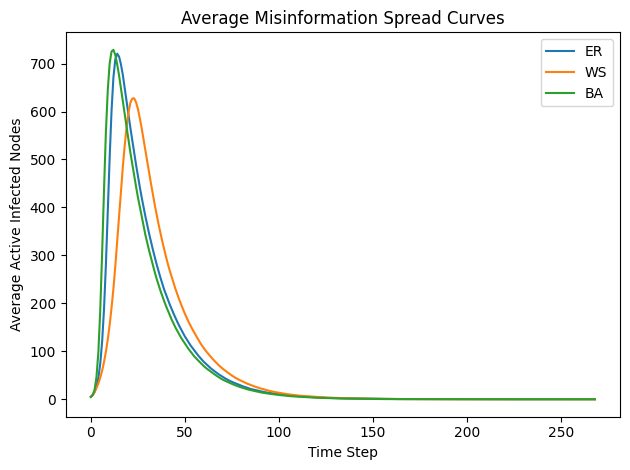

In [12]:
with open(DATA_DIR / "baseline_curves.json", "r") as f:
    curves = json.load(f)

max_length = max(len(item["infected_counts"]) for item in curves)

curve_rows = []

for item in curves:
    curve = item["infected_counts"]
    padded_curve = curve + [0] * (max_length - len(curve))

    for t, infected in enumerate(padded_curve):
        curve_rows.append({
            "topology": item["topology"],
            "trial": item["trial"],
            "time": t,
            "infected": infected
        })

curve_df = pd.DataFrame(curve_rows)

avg_curve = curve_df.groupby(["topology", "time"])["infected"].mean().reset_index()

plt.figure()

for topology in ["ER", "WS", "BA"]:
    subset = avg_curve[avg_curve["topology"] == topology]
    plt.plot(subset["time"], subset["infected"], label=topology)

plt.xlabel("Time Step")
plt.ylabel("Average Active Infected Nodes")
plt.title("Average Misinformation Spread Curves")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_average_curves.png", dpi=300)
plt.show()